# Evaluation Slice Visualisation

This notebook scans the evaluation JSON files under `runs/` and visualises the slice families that help developers understand where the model performs well or poorly:

- `impressions_with_clicked_category`
- `impressions_with_clicked_popularity_bucket`
- `history_len_bucket`
- `time_period`

It compares slice support across JSON files and plots available model metrics such as `ndcg@10` for ranker eval files and retrieval recall at the exact configured cutoff, for example `Recall@200`.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 21,
    "axes.labelsize": 17,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
})
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

## Configuration

Adjust `RUNS_ROOT`, `TOP_N_CATEGORIES`, or `METRICS_TO_PLOT` if you want a narrower view.

In [2]:
ROOT = Path.cwd()
if not (ROOT / "runs").exists() and (ROOT.parent / "runs").exists():
    ROOT = ROOT.parent

RUNS_ROOT = ROOT / "runs"
EVAL_GLOBS = ["*/eval/*.json", "*/retrieval/eval_*.json"]

SLICE_PREFIXES = {
    "clicked_category": "impressions_with_clicked_category__",
    "clicked_popularity_bucket": "impressions_with_clicked_popularity_bucket__",
    "history_len_bucket": "history_len_bucket__",
    "time_period": "time_period__",
}

# Add "recall@10", "auc", or "mrr" here if you want a deeper ranker diagnostic pass.
METRICS_TO_PLOT = ["ndcg@10", "recall_at_k"]
TOP_N_CATEGORIES = 12
MIN_IMPRESSIONS_FOR_METRIC_PLOTS = 25

RUNS_ROOT

WindowsPath('c:/Users/abiga/OneDrive/Documents/MIND_Multistage_Recommender_with_Knowledge_Graph/runs')

## Load And Tidy Eval Slices

The loader keeps only JSON files with a top-level `slices` object. Files like rerank search summaries remain discoverable in the folder but are skipped unless they contain compatible slice metrics.

In [3]:
def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def infer_eval_metadata(path: Path, payload: dict) -> dict:
    rel = path.relative_to(ROOT)
    parts = rel.parts
    run_name = parts[1] if len(parts) > 1 and parts[0] == "runs" else parts[0]
    stage = "retrieval" if "retrieval" in parts else "ranker_eval" if path.name.startswith("ranker_eval") else "eval"
    split = payload.get("eval_split")
    if not split:
        match = re.search(r"_(val|test|train)\.json$", path.name)
        split = match.group(1) if match else path.stem
    stage_label = {"retrieval": "Retrieval", "ranker_eval": "Ranker", "eval": "Eval"}.get(stage, stage.replace("_", " ").title())
    split_label = str(split).replace("_", " ").title()
    label = f"{stage_label} | {split_label}"
    return {"path": str(rel), "run": run_name, "stage": stage, "split": split, "file_label": label, "eval_k": payload.get("k")}


def parse_slice_key(key: str) -> tuple[str | None, str | None]:
    for dimension, prefix in SLICE_PREFIXES.items():
        if key.startswith(prefix):
            return dimension, key[len(prefix):]
    return None, None


def discover_eval_jsons() -> list[Path]:
    paths = []
    for pattern in EVAL_GLOBS:
        paths.extend(RUNS_ROOT.glob(pattern))
    return sorted(set(paths))


def build_slice_frame(paths: list[Path]) -> tuple[pd.DataFrame, pd.DataFrame]:
    records = []
    file_records = []

    for path in paths:
        payload = read_json(path)
        meta = infer_eval_metadata(path, payload)
        slices = payload.get("slices", {})
        has_supported_slices = isinstance(slices, dict) and any(parse_slice_key(k)[0] for k in slices)
        file_records.append({**meta, "has_supported_slices": has_supported_slices, "n_slices": len(slices) if isinstance(slices, dict) else 0})
        if not has_supported_slices:
            continue

        overall = slices.get("overall", {})
        overall_n = overall.get("n_impressions")
        time_period_lookup = {p.get("name"): p for p in payload.get("time_periods", []) if isinstance(p, dict)}

        for slice_key, metrics in slices.items():
            dimension, value = parse_slice_key(slice_key)
            if dimension is None or not isinstance(metrics, dict):
                continue
            record = {
                **meta,
                "slice_key": slice_key,
                "dimension": dimension,
                "value": value,
                "n_impressions": metrics.get("n_impressions", np.nan),
                "overall_n_impressions": overall_n,
            }
            if dimension == "time_period":
                period = time_period_lookup.get(value, {})
                record["time_min"] = period.get("time_min")
                record["time_max"] = period.get("time_max")
            for metric_name, metric_value in metrics.items():
                if metric_name != "n_impressions" and isinstance(metric_value, (int, float)):
                    record[metric_name] = metric_value
            records.append(record)

    df = pd.DataFrame(records)
    files = pd.DataFrame(file_records)
    if not df.empty:
        df["support_share"] = df["n_impressions"] / df["overall_n_impressions"]
        if "time_min" in df and "time_max" in df:
            df["time_min"] = pd.to_datetime(df["time_min"], errors="coerce")
            df["time_max"] = pd.to_datetime(df["time_max"], errors="coerce")
            df["time_mid"] = df["time_min"] + (df["time_max"] - df["time_min"]) / 2
    return df, files


slice_df, file_df = build_slice_frame(discover_eval_jsons())
display(file_df)
display(slice_df.head())

,path,run,stage,split,file_label,eval_k,has_supported_slices,n_slices
0,runs\mind_small_demo\eval\ranker_eval_test.json,mind_small_demo,ranker_eval,test,Ranker | Test,NaN,True,155
1,runs\mind_small_demo\eval\ranker_eval_val.json,mind_small_demo,ranker_eval,val,Ranker | Val,NaN,True,175
2,runs\mind_small_demo\eval\rerank_eval.json,mind_small_demo,eval,test,Eval | Test,NaN,False,0
3,runs\mind_small_demo\eval\rerank_search.json,mind_small_demo,eval,val,Eval | Val,NaN,False,0
4,runs\mind_small_demo\retrieval\eval_test.json,mind_small_demo,retrieval,test,Retrieval | Test,200.0,True,149
5,runs\mind_small_demo\retrieval\eval_val.json,mind_small_demo,retrieval,val,Retrieval | Val,200.0,True,169


,path,run,stage,split,file_label,eval_k,slice_key,dimension,value,n_impressions,overall_n_impressions,ndcg@5,ndcg@10,recall@5,recall@10,map@5,map@10,mrr,auc,time_min,time_max,recall_at_k,support_share,time_mid
0,runs\mind_small_demo\eval\ranker_eval_test.json,mind_small_demo,ranker_eval,test,Ranker | Test,NaN,history_len_bucket__21_plus,history_len_bucket,21_plus,6877,14631,0.348594,0.408725,0.482381,0.651000,0.284883,0.311963,0.371527,0.687064,NaT,NaT,NaN,0.470029,NaT
1,runs\mind_small_demo\eval\ranker_eval_test.json,mind_small_demo,ranker_eval,test,Ranker | Test,NaN,time_period__period_1_of_4,time_period,period_1_of_4,3658,14631,0.329456,0.391123,0.477066,0.652476,0.264633,0.292130,0.343607,0.667981,2019-11-15 13:24:48,2019-11-15 14:11:34,NaN,0.250017,2019-11-15 13:48:11
2,runs\mind_small_demo\eval\ranker_eval_test.json,mind_small_demo,ranker_eval,test,Ranker | Test,NaN,impressions_with_clicked_popularity_bucket__0,clicked_popularity_bucket,0,12819,14631,0.346807,0.406878,0.488123,0.658636,0.284093,0.310780,0.362346,0.658235,NaT,NaT,NaN,0.876153,NaT
3,runs\mind_small_demo\eval\ranker_eval_test.json,mind_small_demo,ranker_eval,test,Ranker | Test,NaN,impressions_with_clicked_category__sports,clicked_category,sports,3052,14631,0.392494,0.452788,0.548953,0.712493,0.314238,0.342400,0.412294,0.693936,NaT,NaT,NaN,0.208598,NaT
4,runs\mind_small_demo\eval\ranker_eval_test.json,mind_small_demo,ranker_eval,test,Ranker | Test,NaN,impressions_with_clicked_category__weather,clicked_category,weather,275,14631,0.156309,0.248061,0.221338,0.480714,0.105233,0.145682,0.238310,0.600257,NaT,NaT,NaN,0.018796,NaT


## Overview Tables

These tables show which slice dimensions and metrics were found before plotting.

In [4]:
if slice_df.empty:
    raise ValueError(f"No supported slice metrics found under {RUNS_ROOT}")

metric_cols = [
    c for c in slice_df.columns
    if c not in {"path", "run", "stage", "split", "file_label", "eval_k", "slice_key", "dimension", "value", "n_impressions", "overall_n_impressions", "support_share", "time_min", "time_max", "time_mid"}
    and pd.api.types.is_numeric_dtype(slice_df[c])
]

coverage = (
    slice_df.groupby(["file_label", "dimension"])
    .agg(n_slices=("slice_key", "nunique"), total_slice_impressions=("n_impressions", "sum"))
    .reset_index()
    .sort_values(["file_label", "dimension"])
)

metric_availability = (
    slice_df.groupby("file_label")[metric_cols]
    .apply(lambda g: g.notna().sum())
    .reset_index()
)

display(coverage)
display(metric_availability)

,file_label,dimension,n_slices,total_slice_impressions
0,Ranker | Test,clicked_category,14,19476
1,Ranker | Test,clicked_popularity_bucket,4,16581
2,Ranker | Test,history_len_bucket,4,14631
3,Ranker | Test,time_period,4,14631
4,Ranker | Val,clicked_category,14,80664
5,Ranker | Val,clicked_popularity_bucket,4,72833
6,Ranker | Val,history_len_bucket,4,58521
7,Ranker | Val,time_period,4,58521
8,Retrieval | Test,clicked_category,14,18885
9,Retrieval | Test,clicked_popularity_bucket,4,16081


,file_label,ndcg@5,ndcg@10,recall@5,recall@10,map@5,map@10,mrr,auc,recall_at_k
0,Ranker | Test,26,26,26,26,26,26,26,26,0
1,Ranker | Val,26,26,26,26,26,26,26,26,0
2,Retrieval | Test,0,0,0,0,0,0,0,0,25
3,Retrieval | Val,0,0,0,0,0,0,0,0,25


## Plot Helpers

In [5]:
DIMENSION_LABELS = {
    "clicked_category": "Clicked Category",
    "clicked_popularity_bucket": "Clicked Item Popularity",
    "history_len_bucket": "History Len Bucket",
    "time_period": "Time Period",
}

METRIC_LABELS = {
    "ndcg@10": "nDCG@10",
    "recall@10": "Recall@10",
    "recall_at_k": "Recall@K",
    "auc": "AUC",
    "mrr": "MRR",
}


def dimension_label(dimension: str) -> str:
    return DIMENSION_LABELS.get(dimension, str(dimension).replace("_", " ").title())


def metric_label(metric: str, data: pd.DataFrame | None = None) -> str:
    if metric == "recall_at_k" and data is not None and "eval_k" in data:
        ks = sorted({int(k) for k in data["eval_k"].dropna().unique()})
        if len(ks) == 1:
            return f"Recall@{ks[0]}"
        if len(ks) > 1:
            return "Recall@K"
    return METRIC_LABELS.get(metric, metric)


def pretty_value(value: str, dimension: str | None = None) -> str:
    value = str(value)
    if dimension in {"history_len_bucket", "clicked_popularity_bucket"}:
        label = value.replace("_plus", "+").replace("_", "-")
        return f"{label} clicks"
    if dimension == "time_period":
        return re.sub(r"period_(\d+)_of_(\d+)", r"Period \1/\2", value)
    return value.replace("_plus", "+").replace("_", " ").title()


def sort_values_for_dimension(values: list[str], dimension: str) -> list[str]:
    def bucket_key(value: str) -> tuple[int, str]:
        value = str(value)
        period = re.search(r"period_(\d+)_of_(\d+)", value)
        if period:
            return int(period.group(1)), value
        first_number = re.search(r"\d+", value)
        if first_number:
            return int(first_number.group(0)), value
        return 10_000, value

    if dimension in {"history_len_bucket", "clicked_popularity_bucket", "time_period"}:
        return sorted(values, key=bucket_key)
    totals = (
        slice_df[slice_df["dimension"].eq(dimension)]
        .groupby("value")["n_impressions"]
        .sum()
        .sort_values(ascending=False)
    )
    return [v for v in totals.index if v in values]


def filtered_dimension_frame(dimension: str, top_n_categories: int | None = TOP_N_CATEGORIES) -> pd.DataFrame:
    data = slice_df[slice_df["dimension"].eq(dimension)].copy()
    if dimension == "clicked_category" and top_n_categories:
        keep = data.groupby("value")["n_impressions"].sum().nlargest(top_n_categories).index
        data = data[data["value"].isin(keep)].copy()
    return data


def plot_grouped_bar(data: pd.DataFrame, value_col: str, title: str, ylabel: str, dimension: str, figsize=(12, 5)) -> None:
    pivot = data.pivot_table(index="value", columns="file_label", values=value_col, aggfunc="mean")
    order = sort_values_for_dimension(list(pivot.index), dimension)
    pivot = pivot.reindex(order)

    labels = [pretty_value(v, dimension) for v in pivot.index]
    x = np.arange(len(labels))
    n_files = max(len(pivot.columns), 1)
    width = min(0.8 / n_files, 0.28)

    fig, ax = plt.subplots(figsize=figsize)
    for i, col in enumerate(pivot.columns):
        offset = (i - (n_files - 1) / 2) * width
        ax.bar(x + offset, pivot[col].values, width=width, label=col)

    ax.set_title(title, weight="bold", pad=14)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    if value_col == "support_share":
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
    ax.margins(x=0.02)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_support_shares(dimension: str) -> None:
    data = filtered_dimension_frame(dimension)
    if data.empty:
        return
    plot_grouped_bar(
        data=data,
        value_col="support_share",
        title=f"Eval Population by {dimension_label(dimension)}: Share of Impressions Across JSON Files",
        ylabel="Share of impressions",
        dimension=dimension,
        figsize=(14, 6 if dimension != "clicked_category" else 7),
    )


def plot_time_period_metric(metric: str) -> None:
    data = filtered_dimension_frame("time_period")
    required = {metric, "time_mid"}
    if not required.issubset(data.columns):
        return
    data = data[data[metric].notna() & data["time_mid"].notna() & data["n_impressions"].ge(MIN_IMPRESSIONS_FOR_METRIC_PLOTS)].copy()
    if data.empty:
        return

    fig, ax = plt.subplots(figsize=(14, 6))
    for label, group in data.sort_values("time_mid").groupby("file_label", sort=False):
        group = group.sort_values("time_mid")
        ax.plot(group["time_mid"], group[metric], marker="o", linewidth=2.4, markersize=7, label=label)

    label = metric_label(metric, data)
    ax.set_title(f"{label} Over Time: Chronological Slice Performance", weight="bold", pad=14)
    ax.set_ylabel(label)
    ax.set_xlabel("Impression time")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
    ax.margins(x=0.04)
    fig.autofmt_xdate(rotation=0)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_metric_by_dimension(dimension: str, metric: str) -> None:
    if dimension == "time_period":
        plot_time_period_metric(metric)
        return
    data = filtered_dimension_frame(dimension)
    data = data[data[metric].notna() & data["n_impressions"].ge(MIN_IMPRESSIONS_FOR_METRIC_PLOTS)].copy() if metric in data else pd.DataFrame()
    if data.empty:
        return
    plot_grouped_bar(
        data=data,
        value_col=metric,
        title=f"{metric_label(metric, data)} by {dimension_label(dimension)}: Slice-Level Model Performance",
        ylabel=metric_label(metric, data),
        dimension=dimension,
        figsize=(14, 6 if dimension != "clicked_category" else 7),
    )

## Cross-File Slice Support

These plots compare the distribution of impressions across eval JSON files. They are useful for spotting whether validation/test files are similarly composed and whether a metric slice has enough examples to trust.

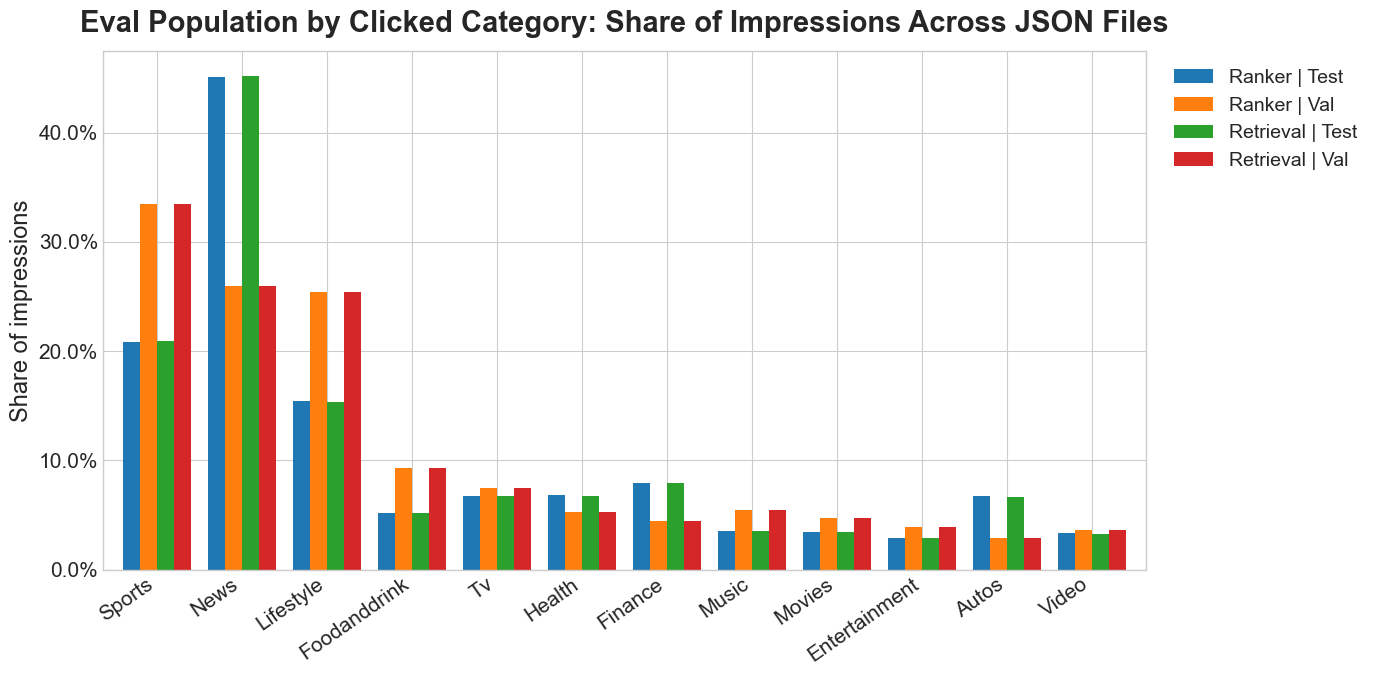

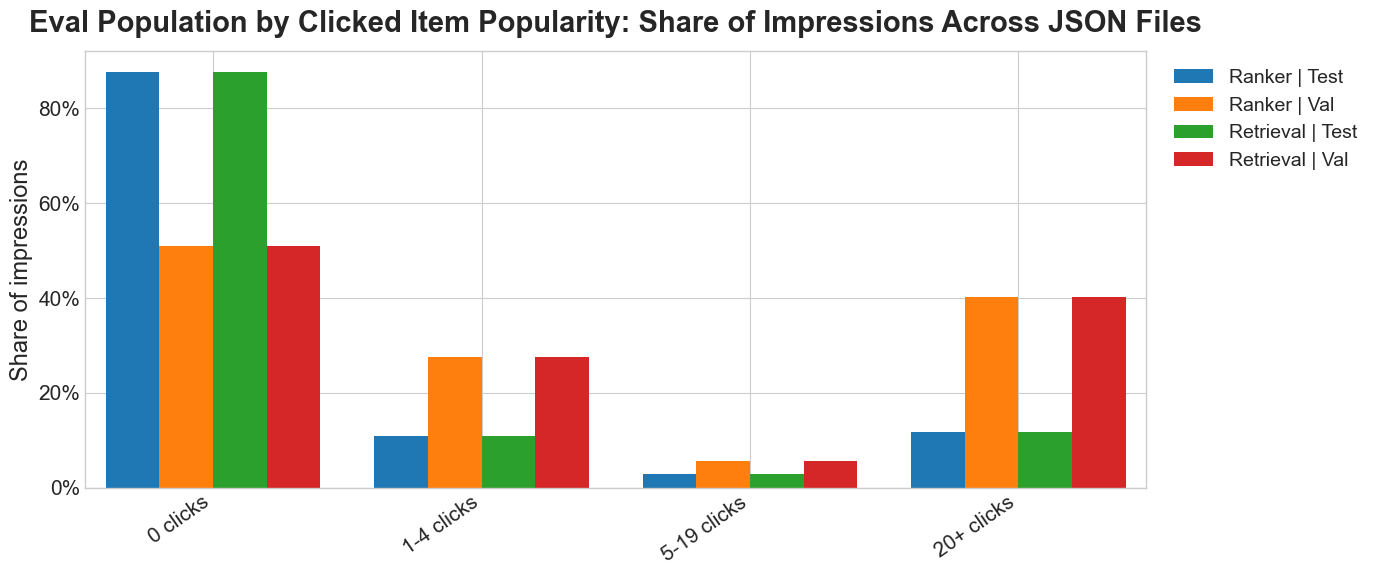

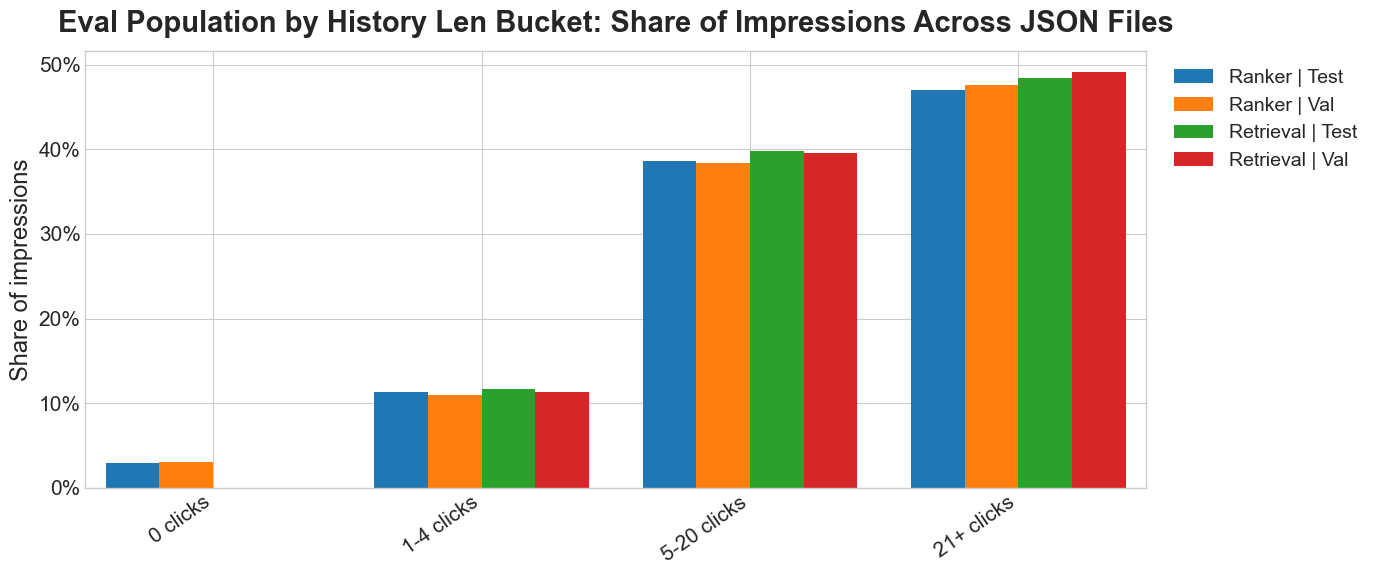

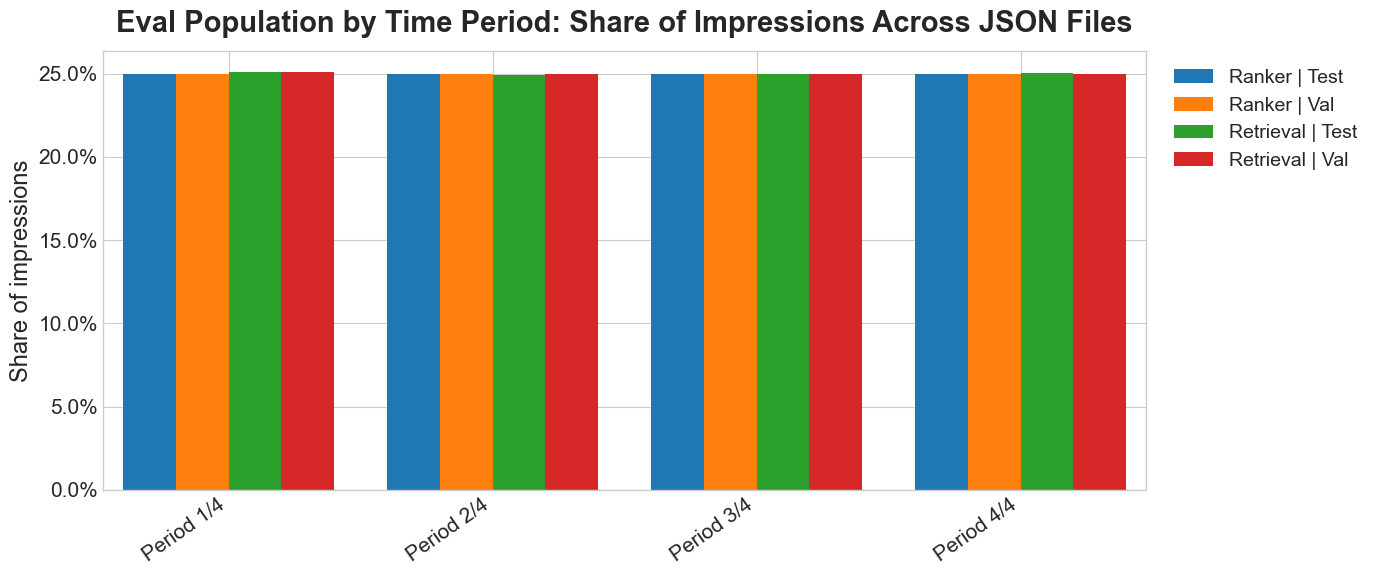

In [6]:
for dimension in SLICE_PREFIXES:
    plot_support_shares(dimension)

## Slice Performance

The next plots use whichever requested metrics are present in each JSON file. Ranker eval files commonly expose `ndcg@10`, `recall@10`, `auc`, and `mrr`; retrieval eval files expose `recall_at_k`.


Metric: nDCG@10


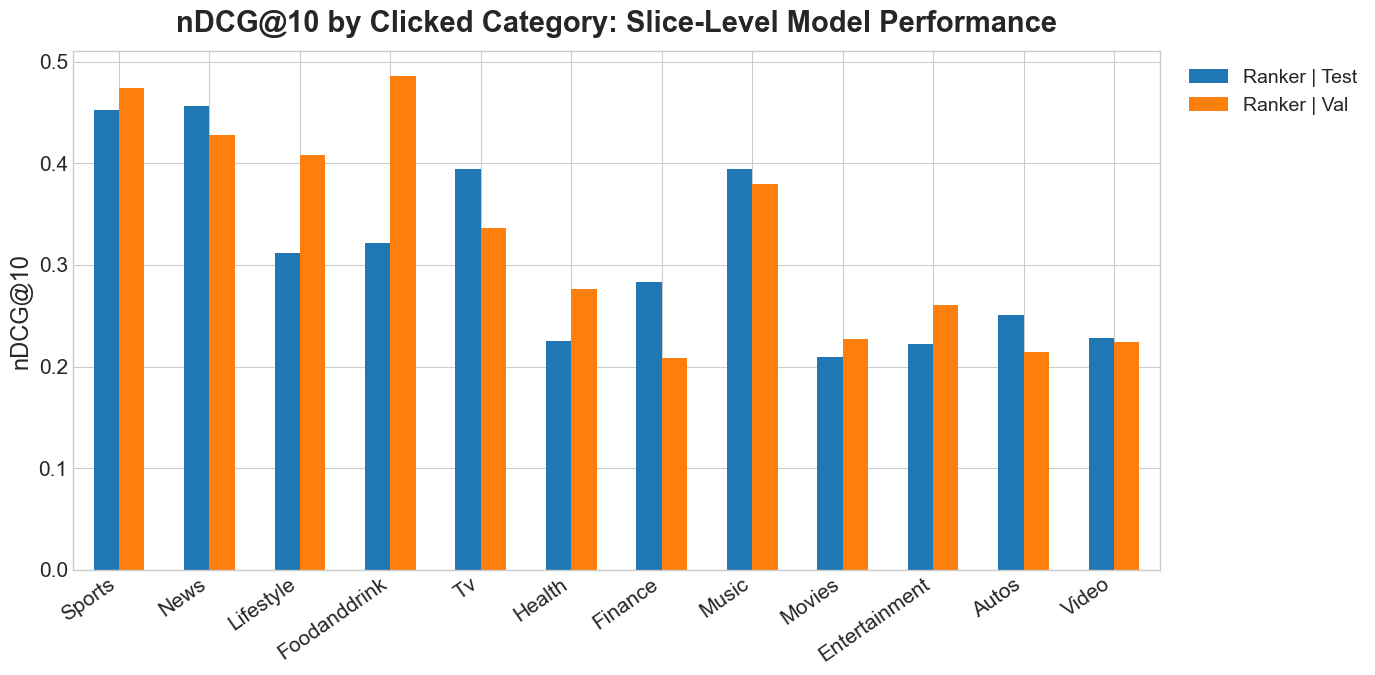

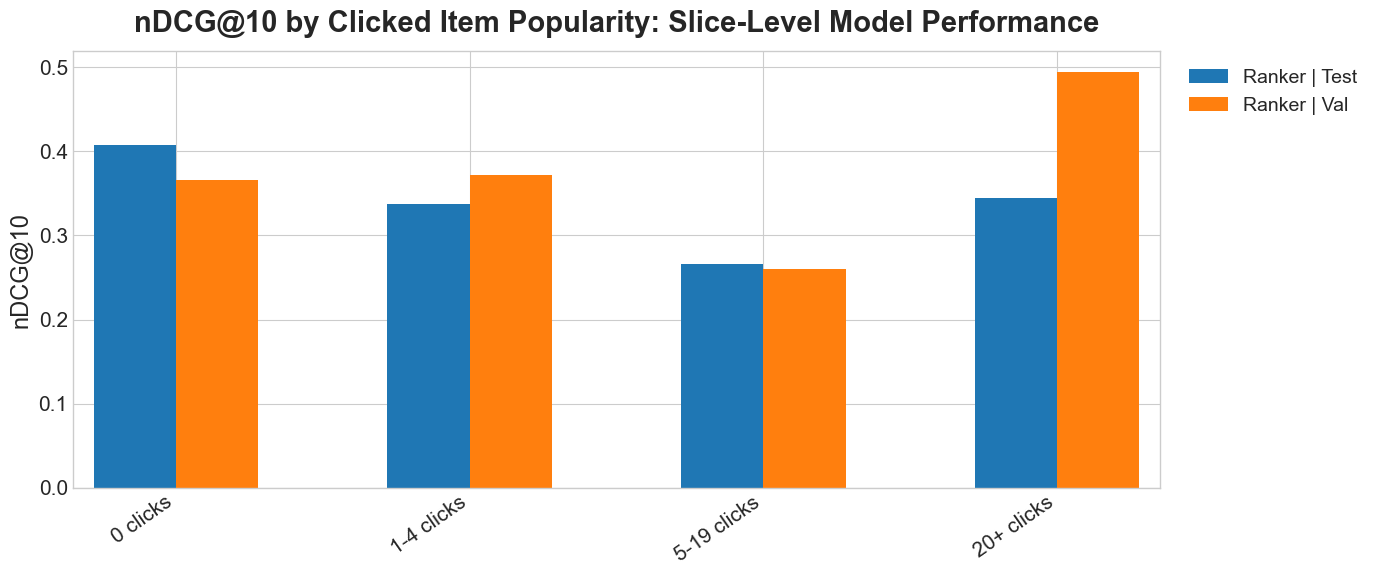

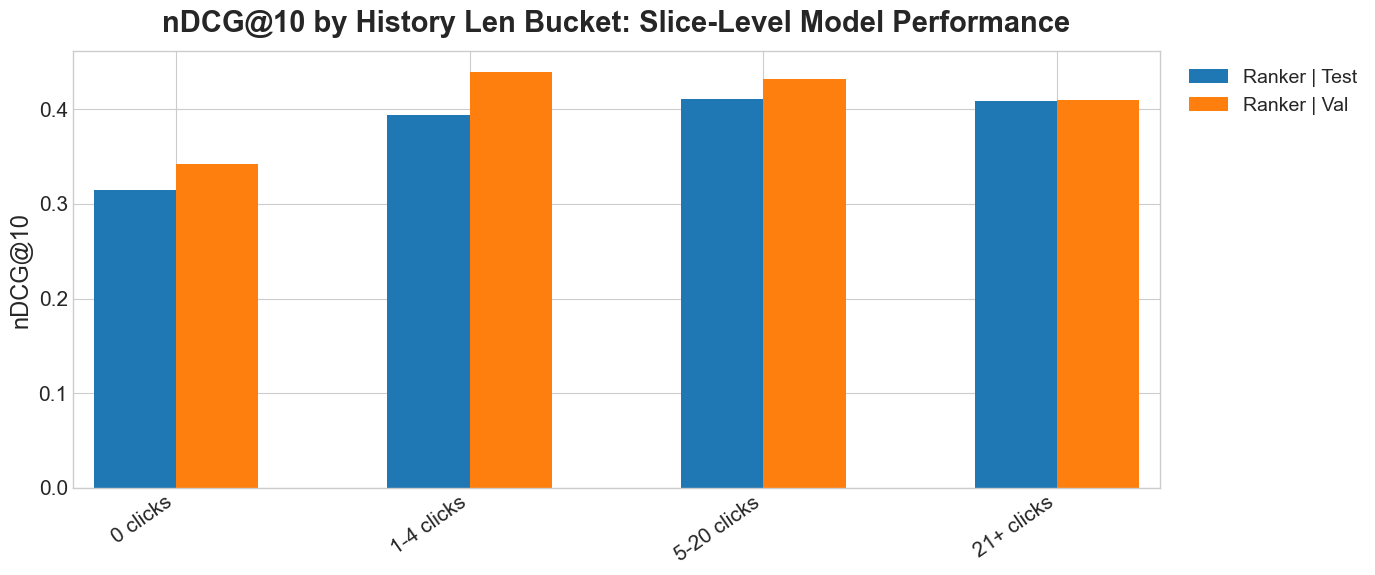

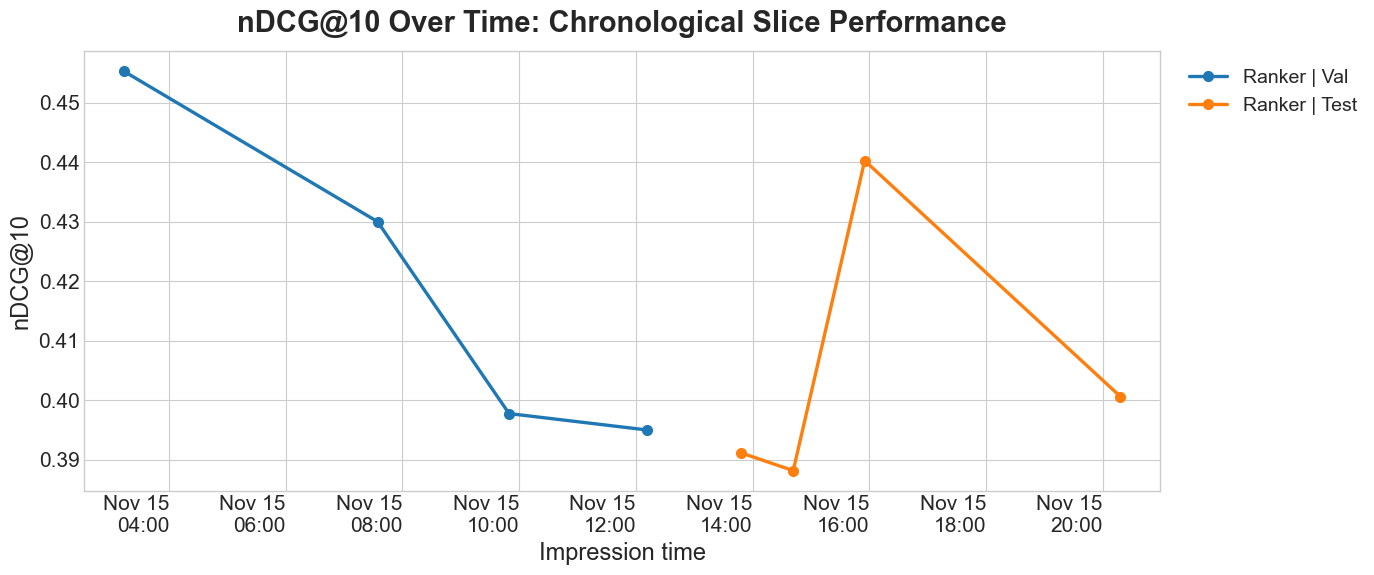


Metric: Recall@200


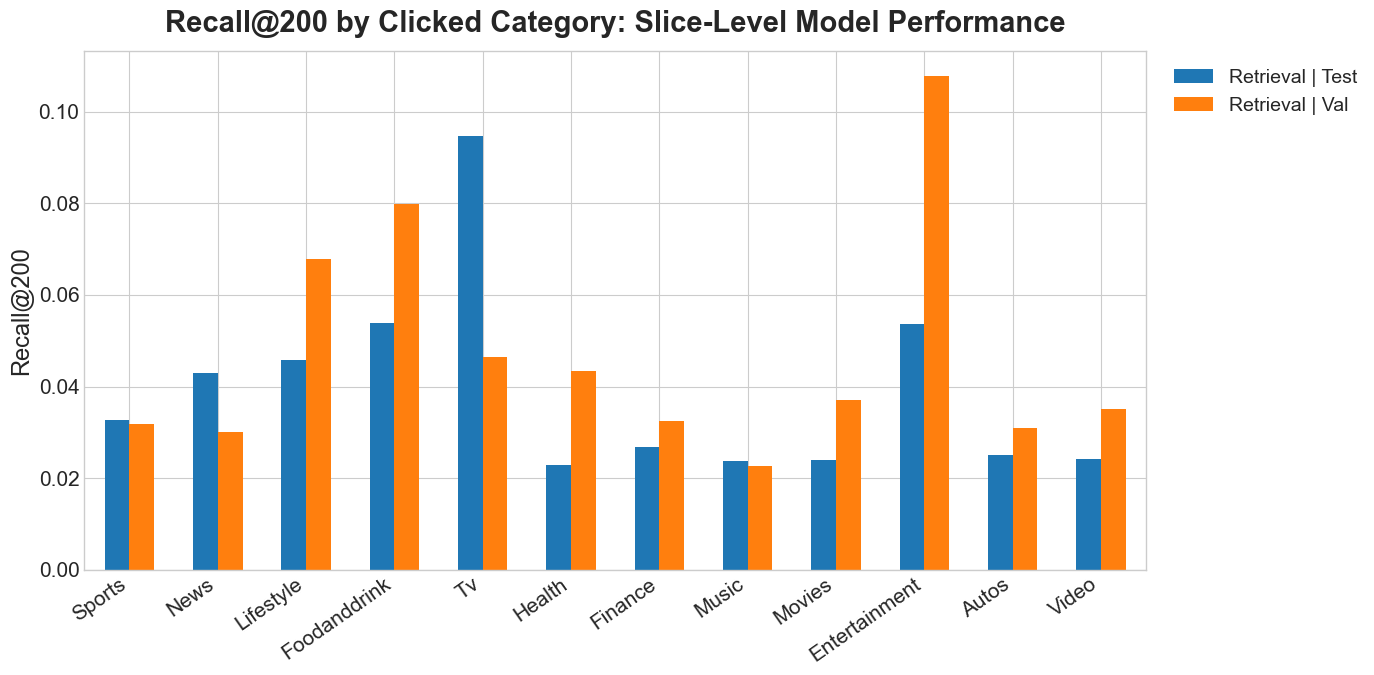

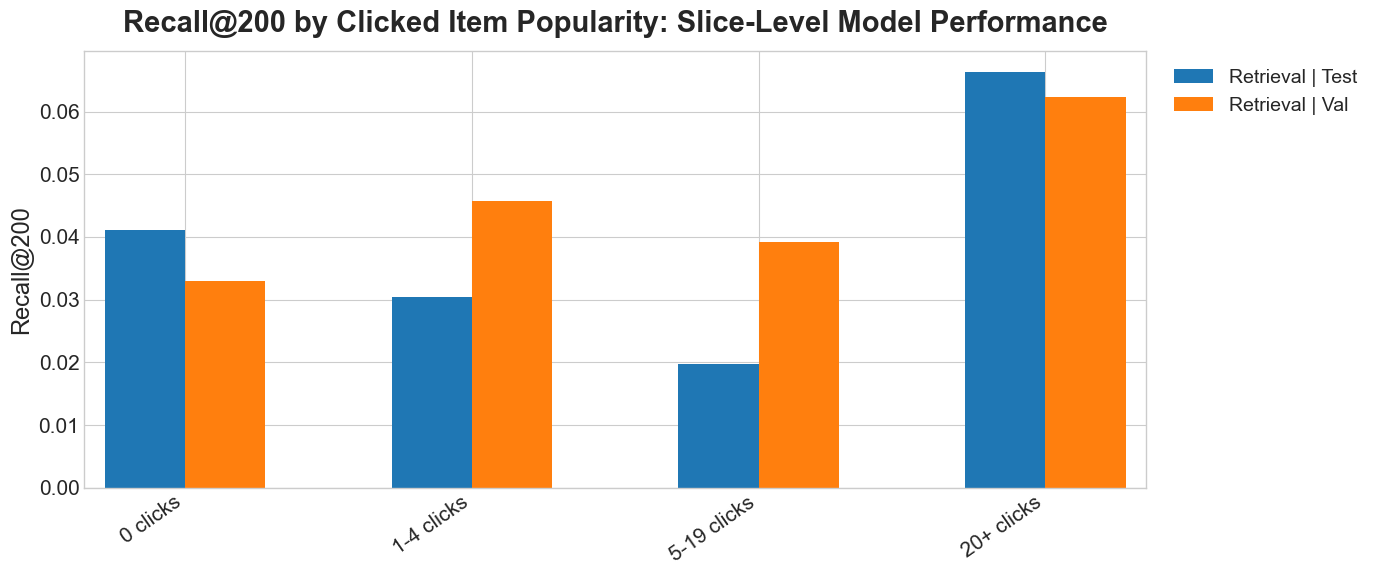

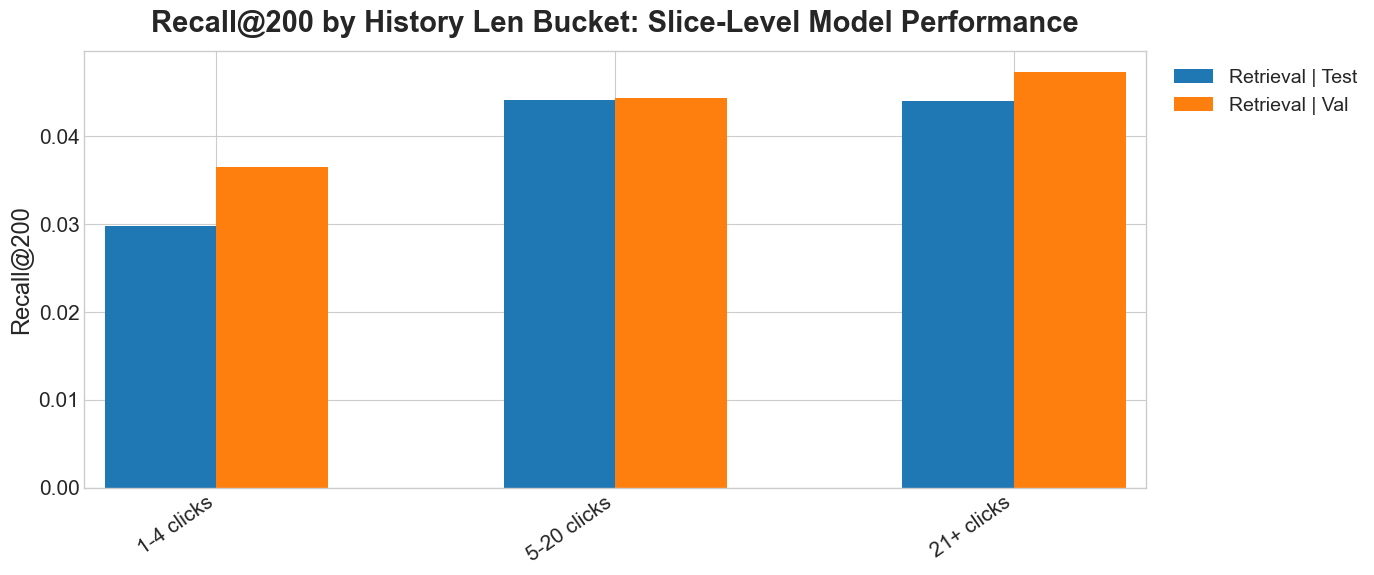

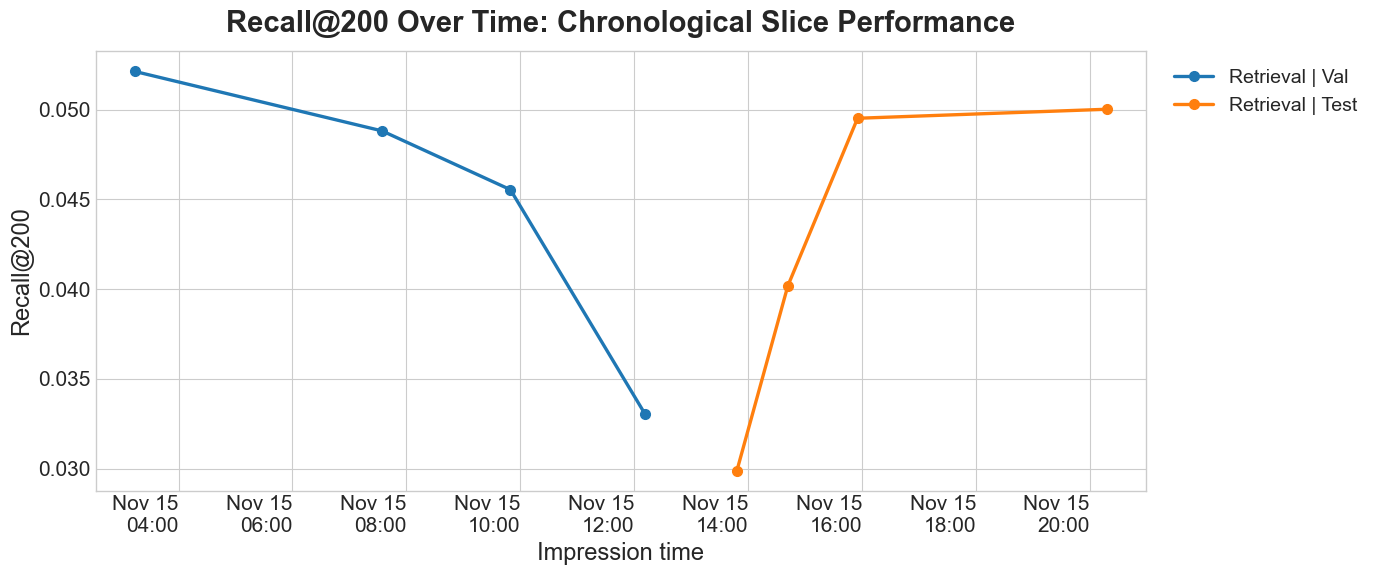

In [7]:
for metric in METRICS_TO_PLOT:
    if metric not in metric_cols:
        continue
    print(f"\nMetric: {metric_label(metric, slice_df)}")
    for dimension in SLICE_PREFIXES:
        plot_metric_by_dimension(dimension, metric)

## Highest And Lowest Slices

This table highlights slices that most deserve developer attention. Low-performing large slices are usually better debugging targets than tiny slices with noisy metrics.

In [8]:
summary_rows = []
for metric in METRICS_TO_PLOT:
    if metric not in metric_cols:
        continue
    data = slice_df[slice_df[metric].notna() & slice_df["n_impressions"].ge(MIN_IMPRESSIONS_FOR_METRIC_PLOTS)].copy()
    for file_label, group in data.groupby("file_label"):
        for dimension, dim_group in group.groupby("dimension"):
            bottom = dim_group.nsmallest(3, metric)
            top = dim_group.nlargest(3, metric)
            for tag, selected in [("lowest", bottom), ("highest", top)]:
                for _, row in selected.iterrows():
                    summary_rows.append({
                        "file_label": file_label,
                        "dimension": dimension,
                        "slice": pretty_value(row["value"], dimension),
                        "metric": metric_label(metric, selected),
                        "position": tag,
                        "value": row[metric],
                        "n_impressions": int(row["n_impressions"]),
                        "support_share": row["support_share"],
                    })

attention_table = pd.DataFrame(summary_rows).sort_values(["metric", "file_label", "dimension", "position", "value"])
display(attention_table)

,file_label,dimension,slice,metric,position,value,n_impressions,support_share
53,Retrieval | Test,clicked_category,Entertainment,Recall@200,highest,0.053757,415,0.029238
52,Retrieval | Test,clicked_category,Foodanddrink,Recall@200,highest,0.053776,736,0.051853
51,Retrieval | Test,clicked_category,Tv,Recall@200,highest,0.094730,956,0.067352
48,Retrieval | Test,clicked_category,Weather,Recall@200,lowest,0.004191,267,0.018811
49,Retrieval | Test,clicked_category,Health,Recall@200,lowest,0.022819,961,0.067705
...,...,...,...,...,...,...,...,...
46,Ranker | Val,time_period,Period 2/4,nDCG@10,highest,0.430036,14630,0.249996
45,Ranker | Val,time_period,Period 1/4,nDCG@10,highest,0.455312,14631,0.250013
42,Ranker | Val,time_period,Period 4/4,nDCG@10,lowest,0.394979,14630,0.249996
43,Ranker | Val,time_period,Period 3/4,nDCG@10,lowest,0.397735,14630,0.249996
